# Caso-taller: ¿Dónde abrir una nueva sede?
## Análisis de Componentes Principales, clasificación de ciudades y recomendación ejecutiva

**Grupo 29 — MIAD Aprendizaje No Supervisado — Módulo 1**

---

### El problema

La empresa evalúa abrir una nueva sede con capacidad para alrededor de 500 empleados entre **329 ciudades candidatas**. Nuestra firma consultora debe construir un primer filtro cuantitativo y responder:

> **¿Qué cinco ciudades deberían avanzar a la fase de *due diligence* y qué evidencia justifica su selección?**

Los datos provienen del **Almanaque Calificado de Lugares** (Boyer y Savageau, 1985) y califican cada ciudad en 9 criterios: *Clima y Terreno, Alojamiento, Cuidado de la salud y el medio ambiente, Crimen, Transporte, Educación, Artes, Recreación* y *Economía*. En **Alojamiento** y **Crimen**, un puntaje **menor** es mejor; en las siete variables restantes, un puntaje **mayor** es mejor.

Este cuaderno documenta de forma reproducible el camino que va desde la estructura estadística de los datos (PCA) hasta la construcción de un índice, un ranking, y finalmente una recomendación empresarial.

### Contenido

1. [Exploración de los datos](#paso1)
2. [Cálculo de los componentes principales](#paso2)
3. Interpretación de los componentes 
4. Construcción del índice y del ranking 
5. Evaluación de la robustez y selección de finalistas 
6. Formulación de la recomendación 

<a id='paso1'></a>
## Paso 1. Exploración de los datos

Antes de calcular cualquier componente principal necesitamos entender la calidad, la escala y la estructura de correlación de los datos. Esta sección responde de forma explícita a las preguntas guía del taller:

- ¿Cuántas relaciones por pares existen entre las nueve variables?
- ¿Qué variables presentan escalas muy diferentes?
- ¿Qué consecuencias tendría aplicar PCA sin estandarizar?
- ¿Qué criterios están más correlacionados y qué hipótesis podrían explicar esas relaciones?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import comb

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

RANDOM_STATE = 42

### 1.1 Carga y estructura general

In [ ]:
df = pd.read_csv('data/lugares.csv', encoding='utf-8-sig')
df = df.set_index('Ciudad')

print(f"Dimensiones: {df.shape[0]} ciudades x {df.shape[1]} variables")
df.head()

Dimensiones: 329 ciudades x 9 variables


,Clima y Terreno,Alojamiento,Cuidado de la salud y el medio ambiente,Crimen,Transporte,Educación,Artes,Recreación,Economía
Ciudad,,,,,,,,,
"Abilene,TX",521,6200,237,923,4031,2757,996,1405,7633
"Akron,OH",575,8138,1656,886,4883,2438,5564,2632,4350
"Albany,GA",468,7339,618,970,2531,2560,237,859,5250
"Albany-Schenectady-Troy,NY",476,7908,1431,610,6883,3399,4655,1617,5864
"Albuquerque,NM",659,8393,1853,1483,6558,3026,4496,2612,5727


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 329 entries, Abilene,TX to Yuba-City,CA
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   Clima y Terreno                          329 non-null    int64
 1   Alojamiento                              329 non-null    int64
 2   Cuidado de la salud y el medio ambiente  329 non-null    int64
 3   Crimen                                   329 non-null    int64
 4   Transporte                               329 non-null    int64
 5   Educación                                329 non-null    int64
 6   Artes                                    329 non-null    int64
 7   Recreación                               329 non-null    int64
 8   Economía                                 329 non-null    int64
dtypes: int64(9)
memory usage: 25.7+ KB


In [5]:
missing = df.isna().sum()
n_dupes = df.index.duplicated().sum()

print("Valores faltantes por variable:")
print(missing)
print(f"\nCiudades con nombre duplicado: {n_dupes}")

Valores faltantes por variable:
Clima y Terreno                            0
Alojamiento                                0
Cuidado de la salud y el medio ambiente    0
Crimen                                     0
Transporte                                 0
Educación                                  0
Artes                                      0
Recreación                                 0
Economía                                   0
dtype: int64

Ciudades con nombre duplicado: 0


El conjunto de datos está completo: **329 ciudades únicas, sin valores faltantes**. Las nueve variables son numéricas (puntajes construidos por el Almanaque a partir de indicadores subyacentes), por lo que no se requieren pasos de limpieza ni imputación antes de continuar.

### 1.2 Estadísticas descriptivas y escalas

In [6]:
desc = df.describe().T
desc['rango'] = desc['max'] - desc['min']
desc['cv'] = (desc['std'] / desc['mean']).round(2)
desc.round(1)

,count,mean,std,min,25%,50%,75%,max,rango,cv
Clima y Terreno,329.0,538.7,120.8,105.0,480.0,542.0,592.0,910.0,805.0,0.2
Alojamiento,329.0,8346.6,2385.3,5159.0,6760.0,7877.0,9015.0,23640.0,18481.0,0.3
Cuidado de la salud y el medio ambiente,329.0,1185.7,1003.0,43.0,583.0,833.0,1445.0,7850.0,7807.0,0.8
Crimen,329.0,961.1,357.2,308.0,707.0,947.0,1156.0,2498.0,2190.0,0.4
Transporte,329.0,4210.1,1451.2,1145.0,3141.0,4080.0,5205.0,8625.0,7480.0,0.3
Educación,329.0,2814.9,320.8,1701.0,2619.0,2794.0,3012.0,3781.0,2080.0,0.1
Artes,329.0,3150.9,4642.3,52.0,778.0,1871.0,3844.0,56745.0,56693.0,1.5
Recreación,329.0,1846.0,807.9,300.0,1316.0,1670.0,2176.0,4800.0,4500.0,0.4
Economía,329.0,5525.4,1084.5,3045.0,4842.0,5384.0,6113.0,9980.0,6935.0,0.2


In [7]:
raw_var = df.var().sort_values(ascending=False)
print("Varianza de cada variable en su escala original:")
raw_var

Varianza de cada variable en su escala original:


Artes                                      2.155080e+07
Alojamiento                                5.689478e+06
Transporte                                 2.105921e+06
Economía                                   1.176072e+06
Cuidado de la salud y el medio ambiente    1.006013e+06
Recreación                                 6.526833e+05
Crimen                                     1.275591e+05
Educación                                  1.029081e+05
Clima y Terreno                            1.459464e+04
dtype: float64

**¿Qué variables presentan escalas muy diferentes?** Todas. *Clima y Terreno* se mueve en cientos de puntos (rango de unos ~600), mientras que *Alojamiento* llega a superar los 20,000 puntos y *Artes* tiene observaciones que superan los 50,000. En términos de varianza, la diferencia es todavía más marcada: la varianza de **Artes** (2.16×10⁷) es más de **1,400 veces** la varianza de **Clima y Terreno** (1.46×10⁴).

**¿Qué consecuencias tendría aplicar PCA sin estandarizar?** Como el PCA busca la combinación lineal que **maximiza varianza**, si trabajáramos sobre la matriz de covarianza de los datos en su escala original, el primer componente quedaría dominado casi por completo por *Artes* y *Alojamiento* — no porque sean estadísticamente más informativas, sino simplemente porque sus unidades producen números más grandes. Variables como *Clima y Terreno*, *Educación* o *Crimen* prácticamente no pesarían en el índice, aunque puedan ser igual o más relevantes para la decisión de negocio. Por ello, **estandarizaremos las variables (media 0, varianza 1) antes de calcular el PCA** en el Paso 2; al estandarizar, la matriz de covarianza de los datos coincide con la matriz de correlación.

### 1.3 Distribuciones

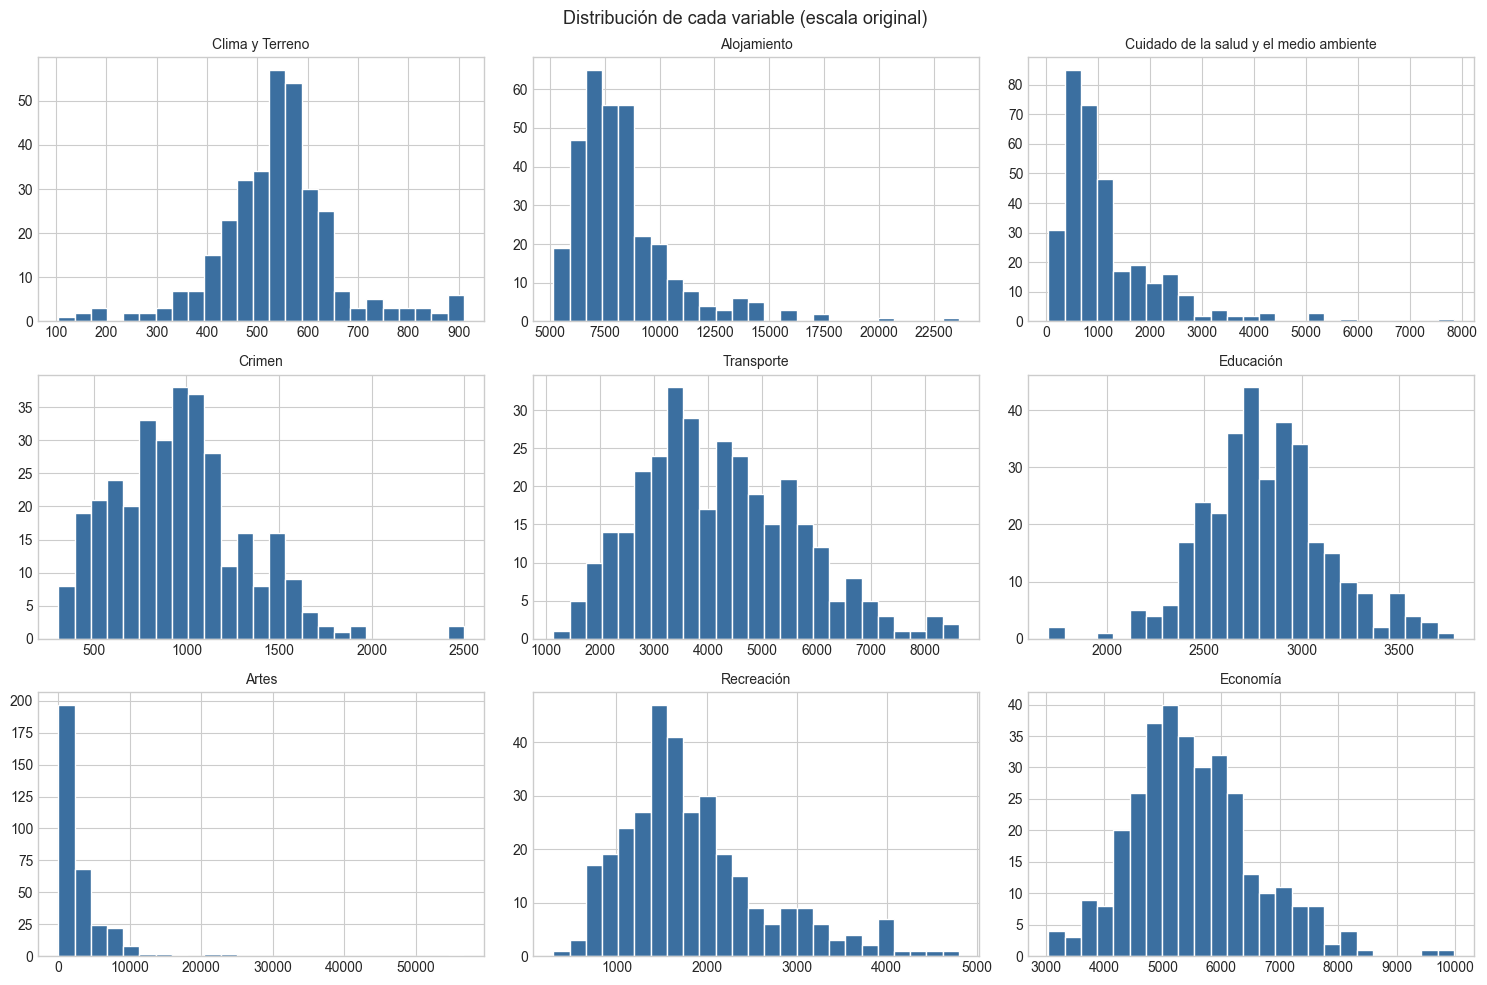

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, df.columns):
    ax.hist(df[col], bins=25, color='#3b6fa0', edgecolor='white')
    ax.set_title(col, fontsize=10)
fig.suptitle('Distribución de cada variable (escala original)', fontsize=13)
plt.tight_layout()
plt.show()

La mayoría de las variables muestran una distribución con cola derecha larga (unas pocas ciudades con puntajes muy altos frente a la mayoría concentrada en valores más bajos o medios). Esto es especialmente visible en *Artes*, *Alojamiento* y *Cuidado de la salud y el medio ambiente*, un patrón consistente con la hipótesis de que unas pocas grandes áreas metropolitanas concentran mucha más oferta cultural, sanitaria y de costo de vida que el resto de las ciudades.

### 1.4 Observaciones atípicas

Estandarizamos únicamente **para fines de comparación visual** (no para el PCA todavía) y marcamos como atípica cualquier observación con normalización $|z| > 3$ en al menos una variable. Siguiendo la guía, **no eliminaremos ninguna observación en esta etapa**: primero identificamos qué ciudades son y qué podría explicar su posición.

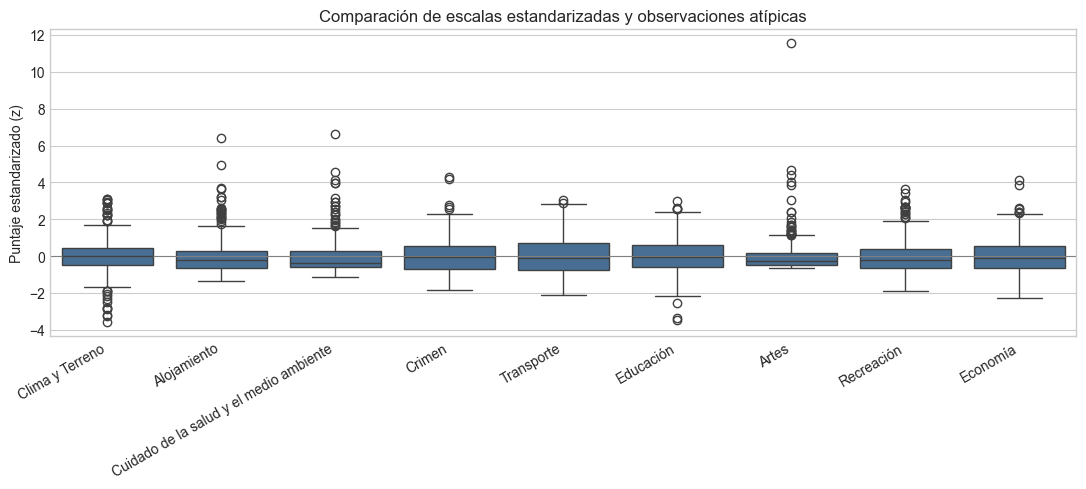

In [9]:
z = (df - df.mean()) / df.std()

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=z, ax=ax, color='#3b6fa0')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_ylabel('Puntaje estandarizado (z)')
ax.set_title('Comparación de escalas estandarizadas y observaciones atípicas')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [10]:
print("Número de ciudades atípicas (|z|>3) por variable:")
print((z.abs() > 3).sum().sort_values(ascending=False))
print()

for col in df.columns:
    flagged = z.index[z[col].abs() > 3]
    if len(flagged):
        print(f"{col}: {list(flagged)}")

Número de ciudades atípicas (|z|>3) por variable:
Alojamiento                                7
Clima y Terreno                            6
Cuidado de la salud y el medio ambiente    6
Artes                                      6
Educación                                  3
Recreación                                 3
Crimen                                     2
Economía                                   2
Transporte                                 1
dtype: int64

Clima y Terreno: ['Bismarck,ND', 'Fargo-Moorhead,ND-MN', 'Grand-Forks,ND', 'Oakland,CA', 'San-Diego,CA', 'San-Francisco,CA']
Alojamiento: ['Anaheim-Santa-Ana,CA', 'Honolulu,HI', 'Norwalk,CT', 'San-Francisco,CA', 'San-Jose,CA', 'Santa-Barbara-Santa-Maria-Lompoc,CA', 'Stamford,CT']
Cuidado de la salud y el medio ambiente: ['Boston,MA', 'Chicago,IL', 'Los-Angeles,Long-Beach,CA', 'New-York,NY', 'Philadelphia,PA-NJ', 'Washington,DC-MD-VA']
Crimen: ['Miami-Hialeah,FL', 'New-York,NY']
Transporte: ['New-York,NY']
Educación: ['Pascago

Un mismo grupo de grandes áreas metropolitanas. **Nueva York, Chicago, Los Ángeles, Boston, Filadelfia, Washington D.C. y San Francisco**. Reaparecen como atípico en varias variables a la vez (*Cuidado de la salud*, *Artes*, y en el caso de Nueva York también *Crimen* y *Transporte*). Esto refuerza la hipótesis de la sección anterior: no son errores de captura, sino el reflejo esperado de ciudades mucho más grandes y densas que el resto de la muestra. Las mantenemos en el análisis, pero las marcamos para revisar en pasos posteriores, qué tanto influyen sobre el ranking final.

### 1.5 Relaciones entre variables

In [11]:
n_vars = df.shape[1]
n_pairs = comb(n_vars, 2)
print(f"Número de variables: {n_vars}")
print(f"Número de relaciones por pares: C({n_vars},2) = {n_pairs}")

Número de variables: 9
Número de relaciones por pares: C(9,2) = 36


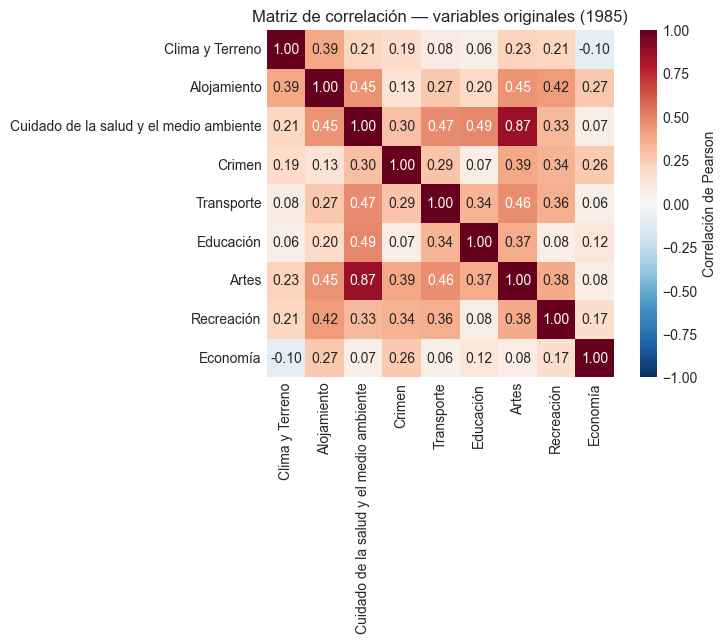

In [12]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'label': 'Correlación de Pearson'})
ax.set_title('Matriz de correlación — variables originales (1985)')
plt.tight_layout()
plt.show()

In [13]:
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pairs = pairs.sort_values(ascending=False)

print("Pares de variables más correlacionados:")
print(pairs.head(6))
print("\nPares de variables menos correlacionados:")
print(pairs.tail(4))

Pares de variables más correlacionados:
Cuidado de la salud y el medio ambiente  Artes                                      0.865796
                                         Educación                                  0.490234
                                         Transporte                                 0.470317
Transporte                               Artes                                      0.464806
Alojamiento                              Cuidado de la salud y el medio ambiente    0.453010
                                         Artes                                      0.448568
dtype: float64

Pares de variables menos correlacionados:
Cuidado de la salud y el medio ambiente  Economía     0.069271
Clima y Terreno                          Educación    0.064520
Transporte                               Economía     0.059247
Clima y Terreno                          Economía    -0.100083
dtype: float64


**¿Qué criterios están más correlacionados y qué hipótesis podrían explicar esas relaciones?**

El par más correlacionado por lejos es **Cuidado de la salud y el medio ambiente y Artes** ($r \approx 0.87$). Le siguen, con correlaciones moderadas ($r \approx 0.42$–$0.49$), *Cuidado de la salud y Educación*, *Cuidado de la salud y Transporte*, *Transporte y Artes* y *Alojamiento y Cuidado de la salud / Artes / Recreación*. En el otro extremo, **Economía** es casi independiente del resto de las variables (correlaciones cercanas a 0, incluso ligeramente negativa con *Clima y Terreno*).

**Hipótesis de trabajo — un factor de "tamaño / densidad metropolitana":** las variables que más covarían (Alojamiento, Salud, Transporte, Artes, Recreación y, en menor medida, Crimen) son precisamente aquellas que tienden a escalar con el tamaño de una ciudad: las áreas metropolitanas grandes concentran más hospitales y oferta cultural, pero también rentas más altas, sistemas de transporte más grandes y más crimen. Esto es coherente con que el mismo grupo de ciudades (Nueva York, Chicago, Boston, Filadelfia, Los Ángeles, Washington D.C.) apareciera como atípico en varias de esas variables en la sección anterior. Si esta hipótesis se confirma en el Paso 3, es probable que el **primer componente principal capture, en buena parte, este eje de tamaño/urbanización**, y no necesariamente el eje de "calidad de vida" que más le interesa al comité — algo que deberemos verificar cuidadosamente al interpretar los componentes.

*Economía* parece responder a una lógica distinta (posiblemente ligada a la estructura productiva local y no al tamaño de la ciudad), por lo que es candidata a formar su propio componente o a cargar débilmente sobre los primeros.

### 1.6 Nota pendiente: dirección de Alojamiento y Crimen

Recordamos, para resolver explícitamente en el **Paso 3**, que en *Alojamiento* y *Crimen* un puntaje **menor** es mejor, mientras que en las siete variables restantes un puntaje **mayor** es mejor. Esta inconsistencia de dirección no afecta el cálculo del PCA en sí (que es puramente una descripción de la varianza y covarianza de los datos), pero sí es crítica para:

1. la **interpretación** de los signos de los *loadings* en cada componente, y
2. la **construcción del índice de atractivo** en el Paso 4, donde todas las variables deberán apuntar consistentemente hacia "mejor = mayor" antes de combinarlas.

Dejamos esta decisión documentada aquí para no tomarla de forma implícita más adelante.

### Cierre del Paso 1 — hallazgos clave

1. Los datos están completos y no requieren limpieza (329 ciudades, 9 variables numéricas, sin nulos ni duplicados).
2. Las variables tienen **escalas muy distintas** (varianzas que difieren en más de 3 órdenes de magnitud) → **es indispensable estandarizar** antes del PCA.
3. Existe un grupo de **grandes áreas metropolitanas** (NY, Chicago, Boston, Filadelfia, LA, Washington D.C., SF) que se comporta como atípico en varias variables simultáneamente — se mantienen en el análisis pero se marcan para el análisis de sensibilidad del Paso 5.
4. La correlación más fuerte (*Salud y Artes*, $r\approx0.87$) y el patrón general de covariación sugieren un posible **factor latente de tamaño/densidad metropolitana**, que deberá contrastarse con la interpretación real de los componentes en el Paso 3.
5. Queda pendiente, y documentada explícitamente, la decisión sobre la **dirección de Alojamiento y Crimen**, a resolver en el Paso 3.

<a id='paso2'></a>
## Paso 2. Cálculo de los componentes principales

### 2.1 Resolviendo la nota pendiente del Paso 1: dirección de Alojamiento y Crimen

Antes de estandarizar, resolvemos explícitamente la nota dejada en la sección 1.6. **Decisión del equipo: invertir el signo de *Alojamiento* y *Crimen*** para que, en las nueve variables, un puntaje más alto sea siempre mejor.

Justificación:

- **Es matemáticamente equivalente** invertir el signo antes o después de estandarizar. Si $y=-x$, entonces $\bar y=-\bar x$ y $s_y=s_x$ (la desviación estándar no cambia porque depende de diferencias al cuadrado), por lo que $z_y=-z_x$. El PCA resultante no cambia en varianza explicada ni en la estructura de los componentes; únicamente cambia el signo del *loading* asociado a estas dos variables.
- Con esta convención, **todos los *loadings* positivos de un componente apuntan hacia "mejor"**, lo que simplifica enormemente la interpretación en el Paso 3 y la construcción del índice de atractivo en el Paso 4, así podremos combinar puntuaciones sin tener que recordar excepciones de signo caso por caso.
- Para dejar la transformación documentada en el propio nombre de la variable, renombramos las columnas invertidas:
  - `Alojamiento` → **Asequibilidad (−Alojamiento)**
  - `Crimen` → **Seguridad (−Crimen)**

A partir de aquí trabajamos con `df_dir`, la versión de los datos con las nueve variables orientadas de forma consistente.

In [ ]:
df_dir = df.copy()
df_dir['Alojamiento'] = -df_dir['Alojamiento']
df_dir['Crimen'] = -df_dir['Crimen']
# Renombrar las variables con cambio de dirección
df_dir = df_dir.rename(columns={
    'Alojamiento': 'Asequibilidad (−Alojamiento)',
    'Crimen': 'Seguridad (−Crimen)'
})

print("Verificación: la correlación con la variable original debe ser exactamente -1")
print(f"  Alojamiento vs Asequibilidad: {np.corrcoef(df['Alojamiento'], df_dir['Asequibilidad (−Alojamiento)'])[0, 1]:.4f}")
print(f"  Crimen vs Seguridad:          {np.corrcoef(df['Crimen'], df_dir['Seguridad (−Crimen)'])[0, 1]:.4f}")

df_dir.tail()

Verificación: la correlación con la variable original debe ser exactamente -1
  Alojamiento vs Asequibilidad: -1.0000
  Crimen vs Seguridad:          -1.0000


,Clima y Terreno,Asequibilidad (−Alojamiento),Cuidado de la salud y el medio ambiente,Seguridad (−Crimen),Transporte,Educación,Artes,Recreación,Economía
Ciudad,,,,,,,,,
"Worcester,MA",562,-8715,1805,-680,3643,3299,1784,910,5040
"Yakima,WA",535,-6440,317,-1106,3731,2491,996,2140,4986
"York,PA",540,-8371,713,-440,2267,2903,1022,842,4946
"Youngstown-Warren,OH",570,-7021,1097,-938,3374,2920,2797,1327,3894
"Yuba-City,CA",608,-7875,212,-1179,2768,2387,122,918,4694


### 2.2 Estandarización

Estandarizamos cada variable de `df_dir` para que tenga media 0 y varianza 1:

$$z_{ij} = \frac{x_{ij}-\bar{x_j}}{s_j}$$

Esto evita que el PCA quede dominado por las variables de mayor escala (ver sección 1.2) y hace que la matriz de covarianza de los datos estandarizados coincida con la matriz de correlación de los datos originales.

In [15]:
z = (df_dir - df_dir.mean()) / df_dir.std()

print("Media tras estandarizar (debe ser ~0):")
print(z.mean().round(10))
print("\nDesviación estándar tras estandarizar (debe ser 1):")
print(z.std().round(4))

Media tras estandarizar (debe ser ~0):
Clima y Terreno                            0.0
Asequibilidad (−Alojamiento)              -0.0
Cuidado de la salud y el medio ambiente   -0.0
Seguridad (−Crimen)                       -0.0
Transporte                                -0.0
Educación                                  0.0
Artes                                      0.0
Recreación                                -0.0
Economía                                  -0.0
dtype: float64

Desviación estándar tras estandarizar (debe ser 1):
Clima y Terreno                            1.0
Asequibilidad (−Alojamiento)               1.0
Cuidado de la salud y el medio ambiente    1.0
Seguridad (−Crimen)                        1.0
Transporte                                 1.0
Educación                                  1.0
Artes                                      1.0
Recreación                                 1.0
Economía                                   1.0
dtype: float64


### 2.3 Descomposición espectral (álgebra lineal)

Calculamos los componentes principales "a mano", descomponiendo la matriz de covarianza $S$ de los datos estandarizados en sus eigenvectores (direcciones, columnas de $P$) y eigenvalores (varianza explicada por cada dirección, diagonal de $\Lambda$):

$$S = P\Lambda P'$$

Cada eigenvector $\delta_j$ define un componente $f_j = Z\delta_j'$, y su eigenvalor $\lambda_j$ es exactamente $\text{Var}(f_j)$.

In [16]:
S = z.cov()

eig_val, eig_vec = np.linalg.eig(S.values)

# Ordenamos de mayor a menor varianza explicada
order = np.argsort(eig_val)[::-1]
eig_val = eig_val[order]
eig_vec = eig_vec[:, order]

pc_names = [f'PC{i+1}' for i in range(len(eig_val))]

print("Eigenvalores (varianza explicada por cada componente), de mayor a menor:")
for name, val in zip(pc_names, eig_val):
    print(f"  {name}: {val:.4f}")

Eigenvalores (varianza explicada por cada componente), de mayor a menor:
  PC1: 3.4083
  PC2: 1.2140
  PC3: 1.1415
  PC4: 0.9209
  PC5: 0.7533
  PC6: 0.6306
  PC7: 0.4930
  PC8: 0.3180
  PC9: 0.1204


In [26]:
# Verificamos que S = P Λ P'
S_reconstructed = eig_vec @ np.diag(eig_val) @ eig_vec.T
print("¿Se reconstruye S = P Λ P' correctamente?", np.allclose(S.values, S_reconstructed))

loadings = pd.DataFrame(eig_vec, index=z.columns, columns=pc_names)
loadings.round(3)
# print((loadings**2).sum())

¿Se reconstruye S = P Λ P' correctamente? True


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Clima y Terreno,0.206,-0.218,0.690,-0.137,-0.369,-0.375,0.085,0.362,0.001
Asequibilidad (−Alojamiento),-0.357,0.251,-0.208,0.512,-0.233,-0.142,-0.231,0.614,-0.014
Cuidado de la salud y el medio ambiente,0.460,0.299,0.007,-0.015,-0.103,0.374,-0.014,0.186,-0.716
Seguridad (−Crimen),-0.281,0.355,0.185,-0.539,0.524,0.081,0.019,0.430,0.059
Transporte,0.351,0.180,-0.146,0.303,0.404,-0.468,0.583,0.094,0.004
Educación,0.275,0.483,-0.230,-0.335,-0.209,-0.502,-0.426,-0.189,0.111
Artes,0.463,0.195,0.026,0.101,-0.105,0.462,0.022,0.204,0.686
Recreación,0.328,-0.384,0.051,0.190,0.530,-0.090,-0.628,0.151,-0.026
Economía,0.135,-0.471,-0.607,-0.422,-0.160,-0.033,0.150,0.405,0.000


In [18]:
# Puntuaciones de cada ciudad en cada componente: F = Z · P
scores_manual = pd.DataFrame(z.values @ eig_vec, index=z.index, columns=pc_names)
scores_manual.tail()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Ciudad,,,,,,,,,
"Worcester,MA",-0.140983,1.642143,0.230877,-1.224202,-0.670711,-0.348114,-0.159054,-0.309008,-0.400504
"Yakima,WA",-1.132624,-0.739830,0.319330,1.115428,0.099816,-0.027811,-0.257803,0.062502,0.144835
"York,PA",-1.708201,0.904933,0.657982,-1.340779,-0.311793,0.344883,-0.170877,-0.136739,0.165862
"Youngstown-Warren,OH",-0.765311,1.075326,0.962153,0.435825,-0.575757,-0.027063,-0.403151,-0.390747,0.057641
"Yuba-City,CA",-1.725960,-0.730340,1.076105,0.551422,-1.017898,0.306287,0.586163,-0.571341,0.087884


### 2.4 Validación con `sklearn`

Repetimos el cálculo con `sklearn.decomposition.PCA` sobre los datos ya estandarizados en `z` (no usamos `StandardScaler` porque volvería a estandarizar con `ddof=0`, mientras que `z.cov()` usa `ddof=1`; alimentar `z` directamente evita esa discrepancia decimal y permite comparar cifra a cifra). Los *loadings* deberían coincidir en magnitud —posiblemente con signo opuesto, ya que el signo de un componente es arbitrario (ver contexto teórico)—.

In [27]:
from sklearn.decomposition import PCA

pca = PCA()
scores_sklearn = pd.DataFrame(pca.fit_transform(z), index=z.index, columns=pc_names)
loadings_sklearn = pd.DataFrame(pca.components_.T, index=z.columns, columns=pc_names)

print("¿Coinciden los eigenvalores manuales con pca.explained_variance_?",
      np.allclose(eig_val, pca.explained_variance_, atol=1e-6))
print("¿Coinciden los loadings en magnitud (con signo posiblemente distinto)?",
      np.allclose(loadings.abs().values, loadings_sklearn.abs().values, atol=1e-6))
print("¿Coinciden las puntuaciones en magnitud (con signo posiblemente distinto)?",
      np.allclose(scores_manual.abs().values, scores_sklearn.abs().values, atol=1e-6))

¿Coinciden los eigenvalores manuales con pca.explained_variance_? True
¿Coinciden los loadings en magnitud (con signo posiblemente distinto)? True
¿Coinciden las puntuaciones en magnitud (con signo posiblemente distinto)? True


### 2.5 Selección del número de componentes

Aplicamos los tres criterios discutidos en la teoría (scree plot, proporción de varianza acumulada y criterio de Kaiser) sobre los mismos 9 eigenvalores.

In [28]:
evr = eig_val / eig_val.sum()
cum_evr = np.cumsum(evr)

resumen = pd.DataFrame({
    'Eigenvalor': eig_val,
    'Prop. Varianza Explicada': evr,
    'Prop. Varianza Acumulada': cum_evr
}, index=pc_names)
resumen.round(4)

,Eigenvalor,Prop. Varianza Explicada,Prop. Varianza Acumulada
PC1,3.4083,0.3787,0.3787
PC2,1.2140,0.1349,0.5136
PC3,1.1415,0.1268,0.6404
PC4,0.9209,0.1023,0.7427
PC5,0.7533,0.0837,0.8264
PC6,0.6306,0.0701,0.8965
PC7,0.4930,0.0548,0.9513
PC8,0.3180,0.0353,0.9866
PC9,0.1204,0.0134,1.0000


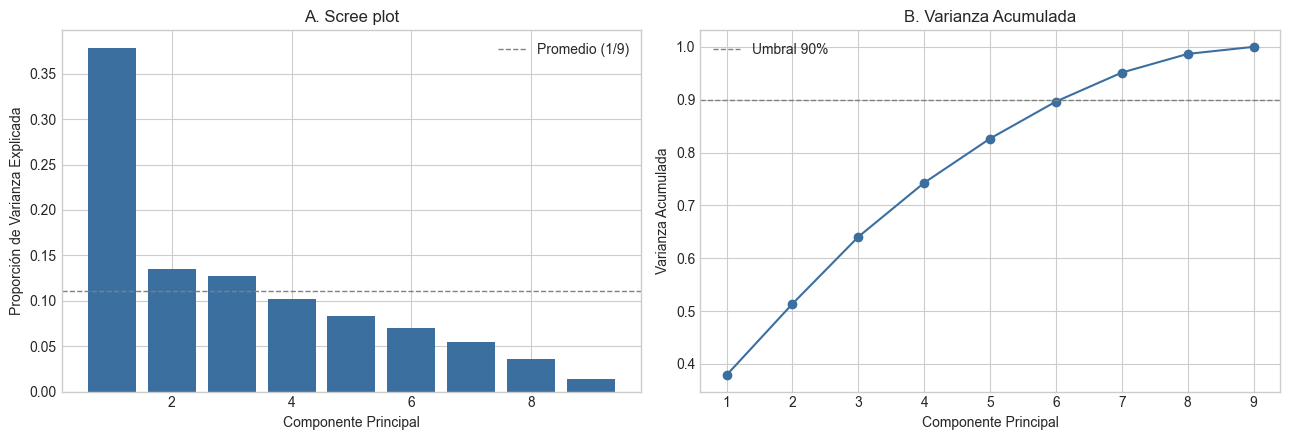

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(1, len(eig_val) + 1), evr, color='#3b6fa0')
axes[0].axhline(1 / len(eig_val), color='grey', linestyle='--', linewidth=1,
                 label=f'Promedio (1/{len(eig_val)})')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Proporción de Varianza Explicada')
axes[0].set_title('A. Scree plot')
axes[0].legend()

axes[1].plot(range(1, len(eig_val) + 1), cum_evr, marker='o', color='#3b6fa0')
axes[1].axhline(0.9, color='grey', linestyle='--', linewidth=1, label='Umbral 90%')
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].set_title('B. Varianza Acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

In [30]:
n_kaiser = int((eig_val > 1).sum())
print(f"Criterio de Kaiser (eigenvalor > 1): {n_kaiser} componentes")
print(eig_val.round(3))

Criterio de Kaiser (eigenvalor > 1): 3 componentes
[3.408 1.214 1.141 0.921 0.753 0.631 0.493 0.318 0.12 ]


**Lectura de los tres criterios (con las 9 variables ya orientadas "mayor = mejor"):**

| Criterio | Resultado |
|---|---|
| Scree plot | Caída pronunciada de PC1 (3.41) a PC2 (1.21); luego una meseta casi plana entre PC2 y PC3 (1.21 → 1.14) antes de otra caída hacia PC4 (0.92). El codo más defendible está **entre PC3 y PC4**. |
| Varianza acumulada | 3 componentes explican **64.0%**; se necesitan 4 para superar el umbral típico de 70% (74.3%) y 7 para superar 90% (95.1%). |
| Kaiser ($\lambda>1$) | Retiene **3 componentes** (PC1=3.41, PC2=1.21, PC3=1.14); PC4 queda apenas debajo (0.92). |

**Decisión: retenemos 3 componentes principales (PC1–PC3).**

Los tres criterios apuntan de forma consistente a un rango entre 3 y 4 componentes, con PC3 y PC4 muy cerca del umbral (1.14 vs. 0.92) — es una frontera genuinamente ambigua, no un caso de manual donde un criterio gane con claridad. Nos quedamos con 3 porque:

1. Es el resultado del criterio de Kaiser, el más objetivo de los tres (no depende de un umbral arbitrario elegido a priori).
2. El 64% de varianza acumulada es razonable para un primer filtro cuantitativo — no buscamos reconstruir los datos originales, sino encontrar los ejes más informativos para diferenciar ciudades.
3. Como veremos en el Paso 3, cada uno de los tres primeros componentes admite una interpretación temática clara, mientras que a partir de PC4 los *loadings* se vuelven más difusos y difíciles de nombrar con confianza.

Dado lo cerrado de la frontera entre 3 y 4 componentes, **usar 4 componentes en lugar de 3 queda registrado como una de las variaciones metodológicas a probar en el análisis de sensibilidad del Paso 5** (tal como sugiere la guía: *"utilizar uno o varios componentes"*).

### Cierre del Paso 2 — hallazgos clave

1. Se resolvió la nota pendiente del Paso 1: **Alojamiento y Crimen quedaron invertidos** (`Asequibilidad`, `Seguridad`) para que las 9 variables compartan la dirección "mayor = mejor".
2. El PCA calculado por álgebra lineal (eigendescomposición de $S$) y por `sklearn` **coinciden exactamente** en eigenvalores, *loadings* (en magnitud) y puntuaciones.
3. Retenemos **3 componentes principales**, que explican el **64.0%** de la varianza total, por criterio de Kaiser y por interpretabilidad (a confirmar en el Paso 3).
4. Queda documentada la alternativa de **4 componentes** como variación a probar en el análisis de sensibilidad del Paso 5.